Loaded: (43405, 67)
default
0    41314
1     2091
Name: count, dtype: int64


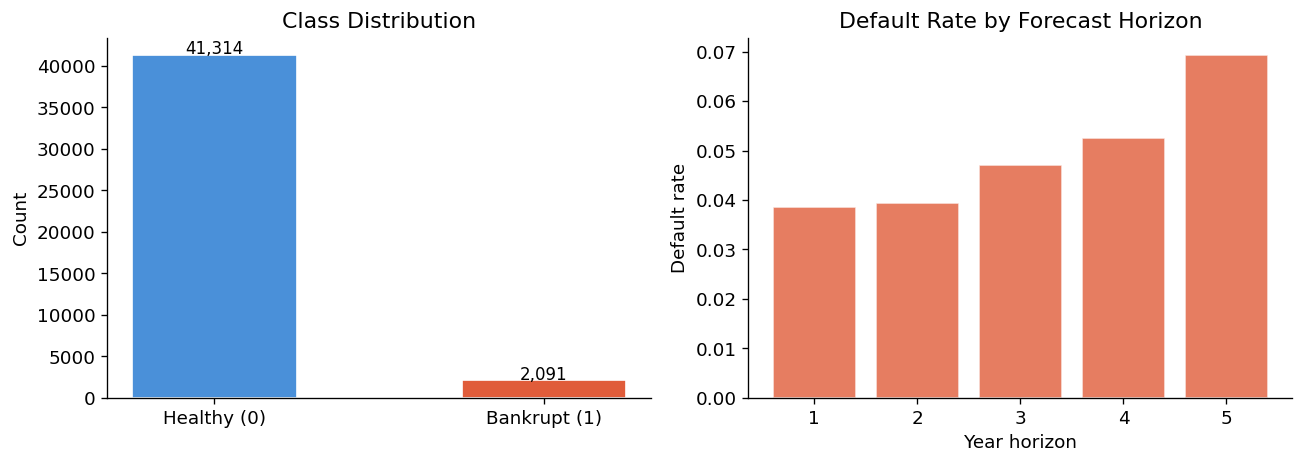

Figure saved: 01_class_distribution.png


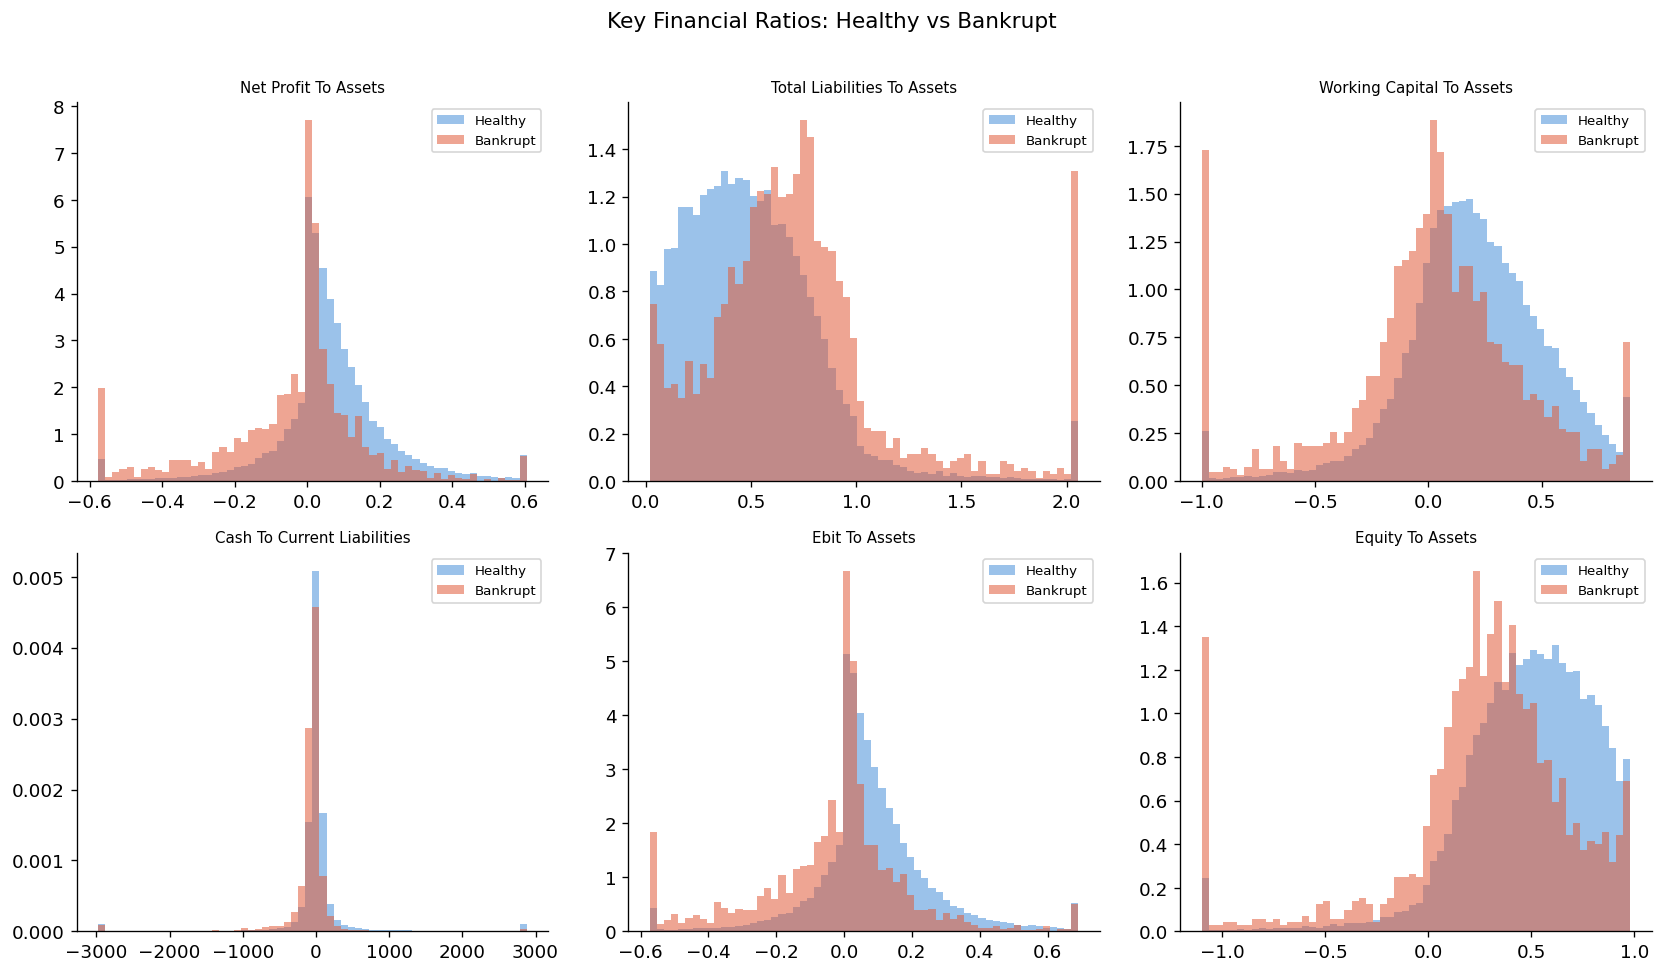

Figure saved: 02_ratio_distributions.png
No missing values found – imputation was already applied in NB01.


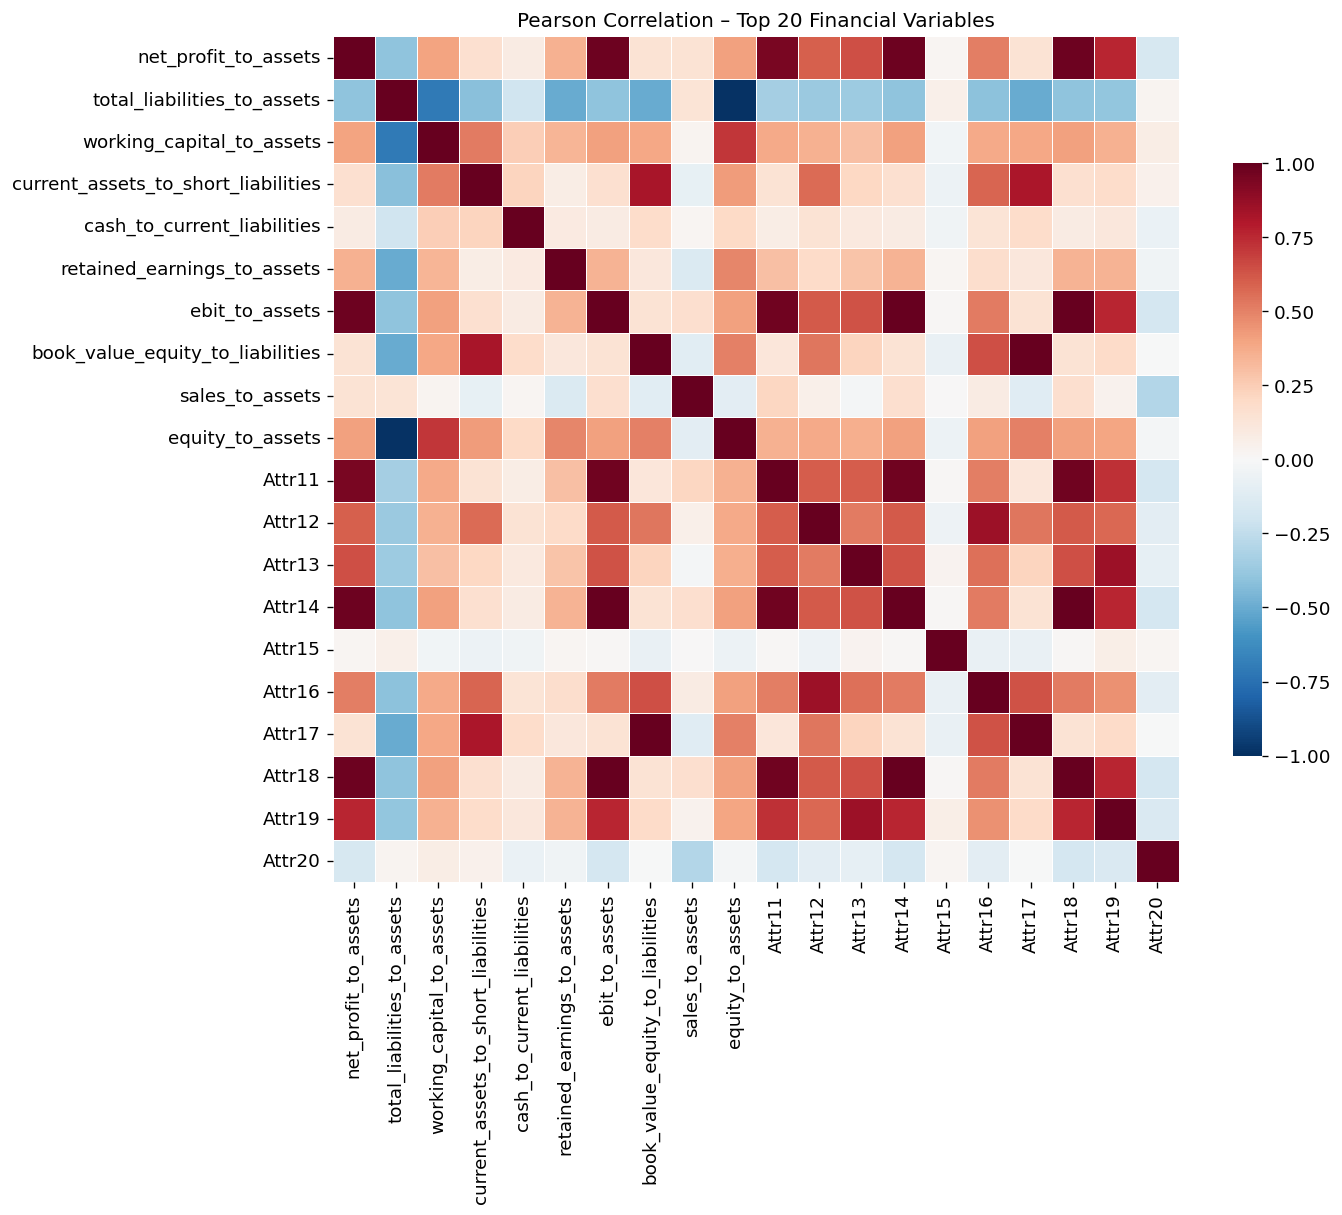

Figure saved: 04_correlation_heatmap.png
Saved: ../results/tables/01_summary_by_default.csv


net_profit_to_assets                 total_liabilities_to_assets  \
                        mean  median     std                        mean   
default                                                                    
0                     0.0670  0.0528  0.1605                      0.4993   
1                    -0.0398  0.0035  0.2050                      0.7213   

                        working_capital_to_assets                  \
         median     std                      mean  median     std   
default                                                             
0        0.4625  0.3254                    0.2075  0.2035  0.3127   
1        0.6684  0.4429                    0.0174  0.0389  0.4063   

        cash_to_current_liabilities                    ebit_to_assets          \
                               mean   median       std           mean  median   
default                                                                         
0                            6.7044   0.4807  521.3714         0.0816  0.0632   
1                          -75.4876 -36.6630  424.4615        -0.0305  0.0051   

                equity_to_assets                  
            std             mean  median     std  
default                                           
0        0.1745           0.4823  0.5152  0.3257  
1        0.2167           0.2570  0.3082  0.4499

Default rate by year horizon:


,n_default,n_total,default_rate
year_horizon,,,
1,271,7027,0.0386
2,400,10173,0.0393
3,495,10503,0.0471
4,515,9792,0.0526
5,410,5910,0.0694


Saved: ../results/tables/02_default_rate_by_horizon.csv


In [2]:
# NB02_eda.ipynb

# %% [markdown]
# # NB02 – Exploratory Data Analysis (EDA)
# **Purpose:** Understand the distribution of financial variables,
# class imbalance, inter-variable correlations, and default rate
# patterns before modelling.
#
# **Input:**  `data/processed/polish_master.parquet`
# **Output:** figures saved to `results/figures/`

# %%
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi"       : 120,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.size"        : 11,
})

PROC_DIR  = "../data/processed/"
FIG_DIR   = "../results/figures/"
TABLE_DIR = "../results/tables/"

os.makedirs(FIG_DIR,   exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

master = pd.read_parquet(PROC_DIR + "polish_master.parquet")
print(f"Loaded: {master.shape}")
print(master["default"].value_counts())

# %% [markdown]
# ## 1. Class balance

# %%
counts = master["default"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
axes[0].bar(
    ["Healthy (0)", "Bankrupt (1)"],
    [counts[0], counts.get(1, 0)],
    color=["#4A90D9", "#E05C3A"],
    width=0.5,
    edgecolor="white",
)
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f"{int(bar.get_height()):,}",
        ha="center", fontsize=10,
    )

# Default rate by year horizon
pivot = (master.groupby("year_horizon")["default"]
               .mean()
               .reset_index()
               .rename(columns={"default": "default_rate"}))
axes[1].bar(pivot["year_horizon"], pivot["default_rate"],
            color="#E05C3A", alpha=0.8, edgecolor="white")
axes[1].set_title("Default Rate by Forecast Horizon")
axes[1].set_xlabel("Year horizon")
axes[1].set_ylabel("Default rate")
axes[1].set_xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.savefig(FIG_DIR + "01_class_distribution.png", bbox_inches="tight")
plt.show()
print("Figure saved: 01_class_distribution.png")

# %% [markdown]
# ## 2. Distribution of key financial ratios (healthy vs bankrupt)

# %%
key_vars = [
    "net_profit_to_assets",
    "total_liabilities_to_assets",
    "working_capital_to_assets",
    "cash_to_current_liabilities",
    "ebit_to_assets",
    "equity_to_assets",
]
key_vars = [v for v in key_vars if v in master.columns]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, key_vars):
    for label, color, subset in [
        ("Healthy",  "#4A90D9", master[master["default"] == 0]),
        ("Bankrupt", "#E05C3A", master[master["default"] == 1]),
    ]:
        ax.hist(subset[col].dropna(), bins=60, alpha=0.55,
                color=color, label=label, density=True)
    ax.set_title(col.replace("_", " ").title(), fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle("Key Financial Ratios: Healthy vs Bankrupt", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR + "02_ratio_distributions.png", bbox_inches="tight")
plt.show()
print("Figure saved: 02_ratio_distributions.png")

# %% [markdown]
# ## 3. Missing value heatmap

# %%
# Show missing pattern across all 64 Attr columns
attr_cols   = [c for c in master.columns if c.startswith("Attr")]
missing_pct = master[attr_cols].isnull().mean().sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

if len(missing_pct) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(range(len(missing_pct)), missing_pct.values * 100,
           color="#888", alpha=0.8, edgecolor="white")
    ax.set_xticks(range(len(missing_pct)))
    ax.set_xticklabels(missing_pct.index, rotation=90, fontsize=7)
    ax.set_ylabel("Missing (%)")
    ax.set_title("Missing Value Rate by Column")
    plt.tight_layout()
    plt.savefig(FIG_DIR + "03_missing_values.png", bbox_inches="tight")
    plt.show()
    print("Figure saved: 03_missing_values.png")
else:
    print("No missing values found – imputation was already applied in NB01.")

# %% [markdown]
# ## 4. Correlation heatmap (top 20 numeric features)

# %%
numeric_cols = master.select_dtypes(include=[float, int]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ("default", "year_horizon")][:20]

corr = master[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr, ax=ax,
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.4, square=True,
    cbar_kws={"shrink": 0.7},
    annot=False,
)
ax.set_title("Pearson Correlation – Top 20 Financial Variables", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR + "04_correlation_heatmap.png", bbox_inches="tight")
plt.show()
print("Figure saved: 04_correlation_heatmap.png")

# %% [markdown]
# ## 5. Summary statistics table (healthy vs bankrupt)

# %%
stat_cols = key_vars

summary = (master.groupby("default")[stat_cols]
                 .agg(["mean", "median", "std"])
                 .round(4))

out_path = TABLE_DIR + "01_summary_by_default.csv"
summary.to_csv(out_path)
print(f"Saved: {out_path}")
display(summary)

# %% [markdown]
# ## 6. Default rate by year horizon (table)

# %%
horizon_table = (master.groupby("year_horizon")["default"]
                       .agg(["sum", "count", "mean"])
                       .rename(columns={"sum": "n_default", "count": "n_total",
                                        "mean": "default_rate"})
                       .round(4))

print("Default rate by year horizon:")
display(horizon_table)
horizon_table.to_csv(TABLE_DIR + "02_default_rate_by_horizon.csv")
print(f"Saved: {TABLE_DIR}02_default_rate_by_horizon.csv")